# Example 01 - Building and evaluating a simple refrigeration cycle

This notebook walks through the same steps of modelling a basic refrigeration cycle.

1. Creating an empty cycle
2. Adding a compressor, condensor, and evaporator
3. Plotting cycle results in log(p)h- and Ts-diagrams


In [1]:
import numpy as np
from CoolProp.CoolProp import AbstractState
import matplotlib.pyplot as plt

from refrigerationtoolbox.cycle.BasicHeatExchanger import BasicHeatExchanger
from refrigerationtoolbox.cycle.Compressor import celsius_to_kelvin_coeffs
from refrigerationtoolbox.cycle.Cycle import Cycle
from refrigerationtoolbox.cycle.EffCompressor import EffCompressor
from refrigerationtoolbox.cycle.PlateHeatExchanger import PlateHeatExchanger
from refrigerationtoolbox.cycle.PolynomialCompressor import PolynomialCompressor
from refrigerationtoolbox.plotter.CyclePlotter import CyclePlotter

## 1. An empty cycle

We use R134a as the refrigerant and water on both secondary loops. The cycle
operates with an evaporating temperature of 0 °C and a condensing
temperature of 30 °C, with 5 K of superheat and no subcooling. Printing the
cycle before running `calc()` shows the states as `N/A`.

In [2]:
Te = 0 + 273.15  # [K] evaporation temperature on the low pressure side
Tc = 30 + 273.15 # [K] condensation temperature on the high pressure side
sh = 5           # [K] superheating at compressor inlet
sc = 0           # [K] subcooling at condensor outlet

# Refrigerant used in the refrigeration cycle
fluid_ref = AbstractState("HEOS", "R134a")

cycle = Cycle(fluid_ref, Te=0+273.15, Tc=30+273.15, sh=5.0, sc=0.0)
print(cycle)

Cycle (refrigerant=R134a, Te=273.15, Tc=303.15, sh=5.0, sc=0.0)
   Q_heat: N/A kW, Q_ref: N/A kW, P_comp: N/A kW, COP_heat=N/A, COP_cool= N/A, m_flow=N/A kg/s
   State 1: T=N/A, P=N/A kPa, h=N/A kJ/kg, s=N/A kJ/(kgK), rho=N/A kg/m³
   State 2: T=N/A, P=N/A kPa, h=N/A kJ/kg, s=N/A kJ/(kgK), rho=N/A kg/m³
   State 3: T=N/A, P=N/A kPa, h=N/A kJ/kg, s=N/A kJ/(kgK), rho=N/A kg/m³
   State 4: T=N/A, P=N/A kPa, h=N/A kJ/kg, s=N/A kJ/(kgK), rho=N/A kg/m³


## 2. Adding an efficiency-based compressor and basic heat exchangers

We now add a compressor, a condenser, and an evaporator to the cycle, using
water on both secondary loops.

The `EffCompressor` model computes the mass flow from the swept volume and
volumetric efficiency, and the discharge state from the isentropic efficiency.
It is parametrised by the isentropic efficiency `is_eff`, the volumetric
efficiency `vol_eff`, the running frequency `N`, and the displaced volume per
revolution `Vd`.

The `BasicHeatExchanger` is a lumped model that solves the secondary-side outlet
state from an energy balance. Each heat exchanger therefore needs its secondary
boundary conditions — the secondary mass flow rate, pressure, and inlet
temperature — which we pass to `cycle.calc()` separately for the condenser and
the evaporator.

Running `calc()` then solves the whole cycle, and we print the overall cycle
states together with the compressor, condenser, and evaporator.

In [3]:
# using water in the secondary cycles of the evaporators and condensers
fluid_sec_evap = AbstractState("HEOS", "Water")
fluid_sec_cond = AbstractState("HEOS", "Water")

# Efficiency-based compressor parameters
is_eff = 0.8  # Isentropic efficiency
vol_eff = 0.9 # Volumetric efficiency
N = 1500 / 60 # [Hz] Compressor frequency (1500 rpm / 60)
Vd = 5e-5     # [m³] Displaced volume per revolution

# Boundary condition at heat exchangers
m_flow_sec_cond = 0.1       # [kg/s] Mass flow rate at the inlet of the secondary cycle of the condenser
p_sec_cond = 1e5            # [Pa] Pressure in the secondary cycle of the condenser
T_sec_in_cond = 20+273.15   # [K] Temperature at the inlet of the secondary cycle of the condenser
m_flow_sec_evap = 0.1       # [kg/s] Mass flow rate at the inlet of the secondary cycle of the evaporator
p_sec_evap = 1e5            # [Pa] Pressure in the secondary cycle of the evaporator
T_sec_in_evap = 10+273.15   # [K] Temperature at the inlet of the secondary cycle of the evaporator

eff_comp = EffCompressor(fluid_ref, is_eff=is_eff, vol_eff=vol_eff, N=N, Vd=Vd)
evaporator = BasicHeatExchanger(fluid_ref, fluid_sec_evap)
condenser = BasicHeatExchanger(fluid_ref, fluid_sec_cond)

cycle.set_compressor(eff_comp)
cycle.set_condenser(condenser)
cycle.set_evaporator(evaporator)

cycle.calc(m_flow_sec_cond=m_flow_sec_cond, p_sec_cond=p_sec_cond, T_sec_in_cond=T_sec_in_cond, m_flow_sec_evap=m_flow_sec_evap, p_sec_evap=p_sec_evap, T_sec_in_evap=T_sec_in_evap)
# Print the cycles states
print("--- Cycle states ---")
print(cycle)
print("\n--- Cycle state ---")
print(cycle.compressor)
print("\n--- Condenser state ---")
print(cycle.condenser)
print("\n--- Evaporator state ---")
print(cycle.evaporator)

--- Cycle states ---
Cycle (refrigerant=R134a, Te=273.15, Tc=303.15, sh=5.0, sc=0.0)
   Q_heat: 2.96 kW, Q_ref: 2.55 kW, P_comp: 0.41 kW, COP_heat=7.27, COP_cool= 6.27, m_flow=0.02 kg/s
   State 1: T=278.15, P=292.80 kPa, h=403.07 kJ/kg, s=1.74 kJ/(kgK), rho=14.07 kg/m³
   State 2: T=316.65, P=770.20 kPa, h=428.82 kJ/kg, s=1.76 kJ/(kgK), rho=34.66 kg/m³
   State 3: T=303.15, P=770.20 kPa, h=241.72 kJ/kg, s=1.14 kJ/(kgK), rho=1187.46 kg/m³
   State 4: T=273.15, P=292.80 kPa, h=241.72 kJ/kg, s=1.15 kJ/(kgK), rho=65.92 kg/m³

--- Cycle state ---
EffCompressor [R134a] (m_flow = 0.02 kg/s, P = 0.41 kW)
  Inlet : T=278.15 K, p=292.80 kPa, h=403.07 kJ/kg, s=1.74 kJ/kgK, d=14.07 kg/m³
  Outlet: T=316.65 K, p=770.20 kPa, h=428.82 kJ/kg, s=1.76 kJ/kgK, d=34.66 kg/m³

--- Condenser state ---
BasicHeatExchanger (cond, Q = 2.96 kW)
  Refrigerant [R134a] (m_flow = 0.02 kg/s p=770.20 kPa):
    Inlet : T=316.65 K, h=428.82 kJ/kg, s=1.76 kJ/kgK, d=34.66 kg/m³
    Outlet: T=303.15 K, h=241.72 kJ/kg, s=1

## Plotting log p-h and T-s diagrams
After successfully calculating all states within the cycle. The results can be visualized
using the `CyclePlotter` class.

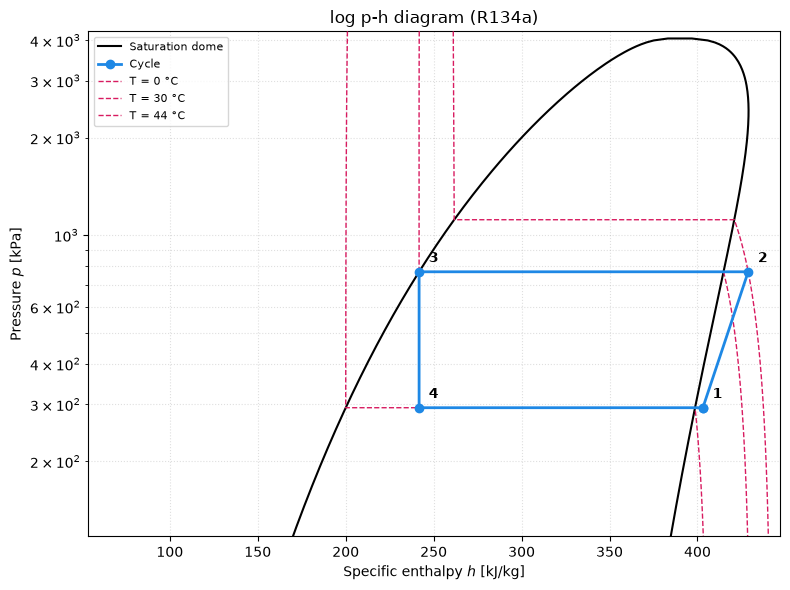

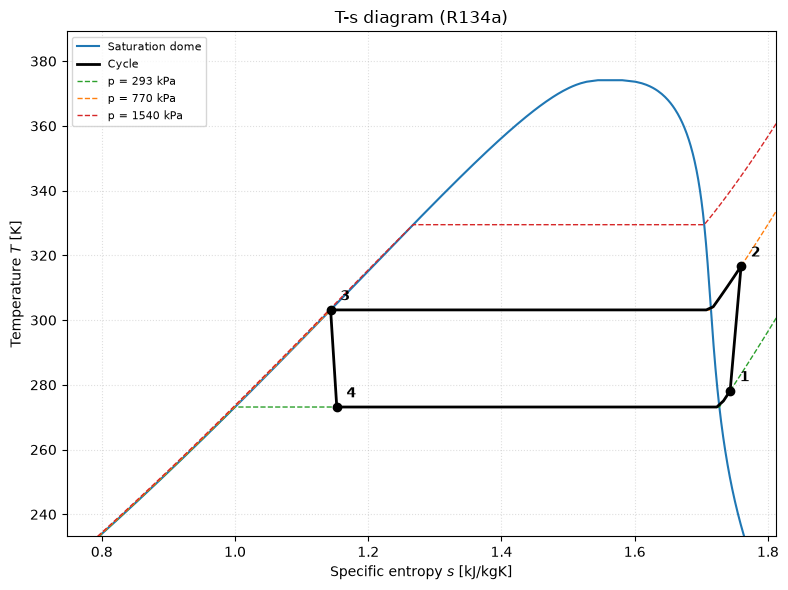

In [4]:
plotter = CyclePlotter()

fig_ph = plt.figure(figsize=(8, 6))
plotter.plot_ph(fig_ph, cycle)
fig_ph.tight_layout()

fig_ts = plt.figure(figsize=(8, 6))
plotter.plot_ts(fig_ts, cycle)
fig_ts.tight_layout()

plt.show()

In [5]:
# m [kg/h]
m_flow_coeffs = celsius_to_kelvin_coeffs(
    np.array([
        433.405599495116, 14.9909912535786, -0.332858512339685,
        0.204623586153767, 0.00783475919685306, -0.00550234077032464,
        0.00147385448738919, 3.00018105510409e-05, -0.000180738817371161,
        -7.5930225497561e-07,
    ]) / 3600  # Convert from kg/h to kg/s
)
# Q [W]
Q_ref_coeffs = celsius_to_kelvin_coeffs(
    np.array([
        24505.1298847642, 923.573745214948, -189.016989612147,
        14.4708589480514, -5.40337736007146, -0.16360259809141,
        0.0859846535814322, -0.0908501243025993, -0.0171380876239127,
        -0.000200200163193361,
    ])
)
# P [W]
P_coeffs = celsius_to_kelvin_coeffs(
    np.array([
        2096.19728039823, 15.1114673839915, 33.2755840370894,
        -0.0533830987334415, -0.194300599703649, 0.433409284725298,
        -0.00897303325535081, 0.00530884169336271, 1.52588234366472e-05,
        0.00607808111008199,
    ])
)

poly_comp = PolynomialCompressor(
    fluid_ref,
    m_flow_coeffs=m_flow_coeffs,
    Q_ref_coeffs=Q_ref_coeffs,
    P_coeffs=P_coeffs,
)
cycle.set_compressor(poly_comp)
cycle.calc()
print(cycle.compressor)

TypeError: Cycle.calc() missing 6 required positional arguments: 'm_flow_sec_cond', 'p_sec_cond', 'T_sec_in_cond', 'm_flow_sec_evap', 'p_sec_evap', and 'T_sec_in_evap'

In [ ]:
geom = {
    "number_of_passes": 1,
    "plate_thickness_m": 0.0007,
    "chevron_angle_rad": 1.0471975511965976,
    "pitch": 0.0025,
    "plate_amplitude_m": 0.001,
    "corrugation_pitch_m": 0.007,
    "Dp": 0.023,
    "Lp": 0.25,
    "Bp": 0.113,
    "Ntmin": 4,
    "Ntmax": 150,
    "m_max": 14.0,
    "Nt": 100,
}

fluid_ref = AbstractState("HEOS", "R134a")
fluid_sec = AbstractState("HEOS", "Water")

heat_exchanger = PlateHeatExchanger(fluid_ref, fluid_sec, geom)
heat_exchanger.calc(
    m_flow_ref=0.01,
    m_flow_sec=0.1,
    h_ref_in=433840,
    h_ref_out=241720,
    p_ref=770200,
    p_sec=100000,
    T_sec_in=20 + 273.15,
)
print(heat_exchanger)

PlateHeatExchanger (cond, Q = 1.92 kW)
  Refrigerant [R134a] (m_flow = 0.01 kg/s p=770.20 kPa):
    Inlet : T=321.61 K, h=433.84 kJ/kg, s=1.78 kJ/kgK, d=33.77 kg/m³
    Outlet: T=303.15 K, h=241.72 kJ/kg, s=1.14 kJ/kgKd=1187.47 kg/m³
  Secondary fluid [Water] (m_flow = 0.10 kg/s, p=100.00 kPa):
    Inlet : T=293.15 K, h=84.01 kJ/kg, s=0.30 kJ/kgK, d=998.21 kg/m³
    Outlet: T=297.74 K, h=103.22 kJ/kg, s=0.36 kJ/kgK, d=997.15 kg/m³
  Nt = 100, dp_ref = 0.01 kPa, dp_sec = 0.15 kPa
